In [2]:
import pandas as pd
import os
import re
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as stats

In [3]:
# ICD chapter ranges
icd_chapters = {
    "A00-B99": "Infectious diseases",
    "C00-D49": "Neoplasms",
    "D50-D89": "Blood and immune disorders",
    "E00-E89": "Metabolic diseases",
    "F01-F99": "Mental disorders",
    "G00-G99": "Nervous system diseases",
    "H00-H59": "Eye diseases",
    "H60-H95": "Ear diseases",
    "I00-I99": "Circulatory diseases",
    "J00-J99": "Respiratory diseases",
    "K00-K95": "Digestive diseases",
    "L00-L99": "Skin diseases",
    "M00-M99": "Musculoskeletal diseases",
    "N00-N99": "Genitourinary diseases",
    "O00-O99": "Pregnancy and childbirth",
    # "P00-P96": "Perinatal period conditions",
    "Q00-Q99": "Congenital disorder",
    "R00-R99": "Symptoms and abnormal findings",
    "S00-T88": "Injury and external causes",
    "V00-Y99": "External causes of morbidity",
    # "Z00-Z99": "Health factors",
    # "U00-U85": "Special purposes",
}
# Roman numerals aligned with the 22 official ICD-10 chapter numbers (I .. XXII)
roman_numerals = [
    "I",   "II",   "III",  "IV",  "V",
    "VI",  "VII",  "VIII", "IX",  "X",
    "XI",  "XII",  "XIII", "XIV", "XV",
    # "XVI", 
    "XVII", "XVIII","XIX", "XX",
    # "XXI", "XXII",
]
chapter2roman_map = {v: r for v, r in zip(icd_chapters.values(), roman_numerals)}
roman2chapter_map = {v: k for k, v in chapter2roman_map.items()}

# color palette
colors = sns.color_palette("tab20", len(roman_numerals))
roman2color_map = dict(zip(roman_numerals, colors))
chapter2color_map = dict(zip(icd_chapters.values(), colors))

### map icd to icd chapters ###

def parse_code(code):
    m = re.match(r"([A-Z]+)(\d+)", str(code))
    if not m:
        return None, None
    letter, number = m.groups()
    number = number[:2]
    return letter, int(number)

def in_range(code, start, end):
    start_l, start_n = parse_code(start)
    end_l, end_n = parse_code(end)
    code_l, code_n = parse_code(code)
    if start_l > code_l:
        return False
    if end_l < code_l:
        return False
    else:
        if start_l < code_l < end_l:
            return True
        if start_l == code_l and end_l == code_l and code_n >= start_n and code_n <= end_n:
            return True
        if start_l == code_l and end_l != code_l and code_n >= start_n:
            return True
        if start_l < code_l and end_l == code_l and code_n <= end_n:
            return True
    return False

def assign_chapter(icd_code):
    for rng, name in icd_chapters.items():
        start, end = rng.split("-")
        if in_range(icd_code, start, end):
            return name
    return "Unknown"

### Construct pmatrix and bmatrix

In [15]:
# get target trait list
temp = pd.read_csv(
    os.path.join(
        "../results",
        "ensemble_prs",
        "aou_ensembleprs_overall_reporttraits.csv"
    )
)

target_trait_list = sorted(temp["icd"].tolist())
n_target_traits = len(target_trait_list)


### Construct square P-matrix in AoU from bidirection selection file ###

bidirection_df = pd.read_csv(
    os.path.join(
        "../results",
        "bidirection_selection",
        "aou_european_bidirection_selection.csv"
    )
)

# Initialize square matrix
pmatrix = np.zeros((n_target_traits, n_target_traits))

# ICD -> matrix index
ticd_to_idx = {
    icd: idx for idx, icd in enumerate(target_trait_list)
}

# Fill square matrix using rank weights
for _, row in bidirection_df.iterrows():
    target_icd = row["target_icd"]
    candidate_icd = row["prs_icd"]
    rank = row["rank"]

    if target_icd not in ticd_to_idx:
        continue

    if candidate_icd not in ticd_to_idx:
        continue

    i = ticd_to_idx[target_icd]
    j = ticd_to_idx[candidate_icd]

    pmatrix[i, j] = 11 - rank


# Convert to DataFrame
aou_smatrix = pd.DataFrame(
    pmatrix,
    index=target_trait_list,
    columns=target_trait_list
)

In [16]:
bidirection_df = pd.read_csv(
    os.path.join(
        "../results",
        "bidirection_selection",
        "ukb_european_bidirection_selection.csv"
    )
)

# Initialize square matrix
pmatrix = np.zeros((n_target_traits, n_target_traits))

# ICD -> matrix index
ticd_to_idx = {
    icd: idx for idx, icd in enumerate(target_trait_list)
}

# Fill square matrix using rank weights
for _, row in bidirection_df.iterrows():
    target_icd = row["target_icd"]
    candidate_icd = row["prs_icd"]
    rank = row["rank"]

    if target_icd not in ticd_to_idx:
        continue

    if candidate_icd not in ticd_to_idx:
        continue

    i = ticd_to_idx[target_icd]
    j = ticd_to_idx[candidate_icd]

    pmatrix[i, j] = 11 - rank


# Convert to DataFrame
ukb_smatrix = pd.DataFrame(
    pmatrix,
    index=target_trait_list,
    columns=target_trait_list
)

In [17]:
### Construct Bidirectional-matrix ###

A = aou_smatrix.values  # row selects column (target=row, candidate=column)
bidirectional_mask = (A > 0) & (A.T > 0)
# average selection strength between i -> j and j -> i
M_avg = (A + A.T) / 2
# keep only bidirectional pairs
M_bi = np.where(bidirectional_mask, M_avg, 0)
aou_bimatrix = pd.DataFrame(M_bi, index=target_trait_list, columns=target_trait_list)

A = ukb_smatrix.values  # row selects column (target=row, candidate=column)
bidirectional_mask = (A > 0) & (A.T > 0)
# average selection strength between i -> j and j -> i
M_avg = (A + A.T) / 2
# keep only bidirectional pairs
M_bi = np.where(bidirectional_mask, M_avg, 0)
ukb_bimatrix = pd.DataFrame(M_bi, index=target_trait_list, columns=target_trait_list)

In [18]:
# calculate eigenvalues and eigenvectors, then sort

from numpy.linalg import eigh

# Eigendecomposition for both cohorts
eigvals_aou, eigvecs_aou = eigh(aou_bimatrix)
eigvals_ukb, eigvecs_ukb = eigh(ukb_bimatrix)

# Sort eigenvalues/vectors descending for each cohort
idx_aou = np.argsort(eigvals_aou)[::-1]
eigvals_aou = eigvals_aou[idx_aou]
eigvecs_aou = eigvecs_aou[:, idx_aou]

idx_ukb = np.argsort(eigvals_ukb)[::-1]
eigvals_ukb = eigvals_ukb[idx_ukb]
eigvecs_ukb = eigvecs_ukb[:, idx_ukb]

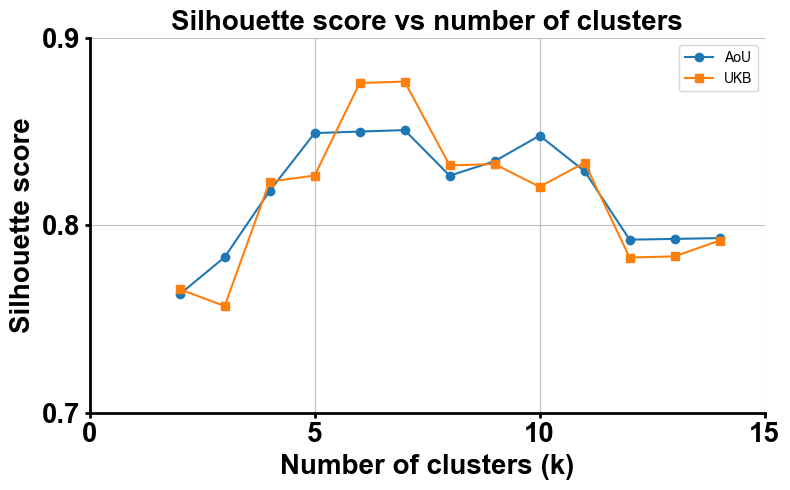

Best k (AoU): 7
Best k (UKB): 7


In [19]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize

# Scan over candidate k values for both cohorts
k_range = range(2, 15)
silhouette_aou = []
silhouette_ukb = []

for k_try in k_range:
    # spectral embedding, then kmeans cluster
    # use silhouette_score to quantify how well is the clustering

    # AoU: top-k eigenvectors, normalize, cluster, score
    features_aou = normalize(eigvecs_aou[:, :k_try], norm="l2")
    labels_aou = KMeans(n_clusters=k_try, random_state=42, n_init=20).fit_predict(features_aou)
    silhouette_aou.append(silhouette_score(features_aou, labels_aou))

    # UKB: top-k eigenvectors, normalize, cluster, score
    features_ukb = normalize(eigvecs_ukb[:, :k_try], norm="l2")
    labels_ukb = KMeans(n_clusters=k_try, random_state=42, n_init=20).fit_predict(features_ukb)
    silhouette_ukb.append(silhouette_score(features_ukb, labels_ukb))

# Plot both silhouette curves on the same figure
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(k_range), silhouette_aou, marker="o", label="AoU")
ax.plot(list(k_range), silhouette_ukb, marker="s", label="UKB")
ax.set_xlabel("Number of clusters (k)", fontsize=20, fontweight='bold')
ax.set_ylabel("Silhouette score", fontsize=20, fontweight='bold')
ax.set_title("Silhouette score vs number of clusters", fontsize=20, fontweight='bold')
ax.legend()

ax.set_ylim(0.7, 0.9)
ax.set_xlim(0, 15)
ax.set_xticks([0, 5, 10, 15])
ax.set_yticks([0.7, 0.8, 0.9])

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.tick_params(width=2)
ax.tick_params(axis='both', labelsize=20, width=2)
ax.tick_params(which='minor', length=8, width=1.5)
ax.grid(axis='both', alpha=0.8)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')

plt.tight_layout()
plt.show()

# Best k for each cohort
best_k_aou = list(k_range)[np.argmax(silhouette_aou)]
best_k_ukb = list(k_range)[np.argmax(silhouette_ukb)]
print(f"Best k (AoU): {best_k_aou}")
print(f"Best k (UKB): {best_k_ukb}")

In [20]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize

k = 7

# aou #
# Take top-k eigenvectors (largest eigenvalues) as features, Cluster on spectral embedding
features = normalize(eigvecs_aou[:, :k], norm="l2")
labels = KMeans(n_clusters=k, random_state=42, n_init=20).fit_predict(features)

aou_cluster_df = pd.DataFrame({"trait": target_trait_list, "cluster": labels}).sort_values("cluster")
aou_cluster_df["chapter"] = aou_cluster_df["trait"].apply(assign_chapter)
aou_cluster_df["chapter_roman"] = aou_cluster_df["chapter"].map(chapter2roman_map)

# ukb #
features = normalize(eigvecs_ukb[:, :k], norm="l2")
labels = KMeans(n_clusters=k, random_state=42, n_init=20).fit_predict(features)

ukb_cluster_df = pd.DataFrame({"trait": target_trait_list, "cluster": labels}).sort_values("cluster")
ukb_cluster_df["chapter"] = ukb_cluster_df["trait"].apply(assign_chapter)
ukb_cluster_df["chapter_roman"] = ukb_cluster_df["chapter"].map(chapter2roman_map)

# relabel ukb clusters #
aou_relabel_map = {
    2: 0,   # mixed
    0: 3,   # injury
    3: 6,   # endocrine/circulatory-ish
    4: 5,   # musculoskeletal
    1: 2,
    5: 1,
    6: 4,
}

aou_cluster_df["cluster"] = aou_cluster_df["cluster"].map(aou_relabel_map)

In [22]:
from itertools import combinations
import numpy as np

def repel_overlapping_nodes(pos, min_dist=0.35, n_iter=100, step=0.5):
    pos = {k: np.array(v, dtype=float) for k, v in pos.items()}

    for _ in range(n_iter):
        for u, v in combinations(pos.keys(), 2):
            delta = pos[u] - pos[v]
            dist = np.linalg.norm(delta)

            if dist < 1e-8:
                delta = np.random.normal(size=2)
                dist = np.linalg.norm(delta)

            if dist < min_dist:
                move = (min_dist - dist) * delta / dist * step
                pos[u] += move
                pos[v] -= move

    return pos

In [23]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.lines import Line2D
from textwrap import fill

matplotlib.rcParams["font.family"] = "Arial"


def plot_one_cluster_network(cohort="aou", cluster_id=0, min_edge_weight=0, label_top_n=5, seed=42, figsize=(5, 5)):
    """
    Visualize one selected cluster from AoU or UKB.

    Required global variables:
        aou_bimatrix, ukb_bimatrix
        aou_cluster_df, ukb_cluster_df
        icd_list
        roman2color_map
    """

    # -----------------------------
    # Select data
    # -----------------------------
    if cohort.lower() == "aou":
        bimatrix = aou_bimatrix
        cluster_df = aou_cluster_df
        title_prefix = "AoU"
    elif cohort.lower() == "ukb":
        bimatrix = ukb_bimatrix
        cluster_df = ukb_cluster_df
        title_prefix = "UKB"
    else:
        raise ValueError("cohort must be either 'aou' or 'ukb'")

    sub_df = cluster_df[cluster_df["cluster"] == cluster_id].copy()
    traits = sub_df["trait"].tolist()

    if len(traits) == 0:
        raise ValueError(f"No traits found for {cohort} cluster {cluster_id}")

    idx = [target_trait_list.index(t) for t in traits]

    A = np.asarray(bimatrix)[np.ix_(idx, idx)].copy()
    np.fill_diagonal(A, 0)

    # remove negative / weak edges
    A[A <= min_edge_weight] = 0

    # -----------------------------
    # Build graph
    # -----------------------------
    G = nx.Graph()

    for _, row in sub_df.iterrows():
        G.add_node(
            row["trait"],
            chapter=row["chapter"],
            chapter_roman=row["chapter_roman"]
        )

    for i in range(len(traits)):
        for j in range(i + 1, len(traits)):
            if A[i, j] > 0:
                G.add_edge(
                    traits[i],
                    traits[j],
                    weight=A[i, j]
                )

    # -----------------------------
    # Layout
    # -----------------------------
    if G.number_of_edges() > 0:
        pos = nx.spring_layout(
            G,
            seed=seed,
            weight=None,
            k=0.8,
            iterations=1000,
        )
        # pos = nx.kamada_kawai_layout(
        #     G,
        #     weight="weight"
        # )
        # pos = nx.kamada_kawai_layout(G, weight=None)
        pos = {n: p * 3.0 for n, p in pos.items()}
        pos = repel_overlapping_nodes(pos, min_dist=1.0, n_iter=200)
    else:
        pos = nx.circular_layout(G)

    # -----------------------------
    # Node / edge aesthetics
    # -----------------------------
    node_colors = [roman2color_map.get(G.nodes[n]["chapter_roman"]) for n in G.nodes()]
    degrees = dict(G.degree())
    node_sizes = [600 + 200 * degrees[n] for n in G.nodes()]

    if G.number_of_edges() > 0:
        weights = np.array([G[u][v]["weight"] for u, v in G.edges()])
        edge_widths = (3.0 + 4.5 * (weights - weights.min()) / (weights.max() - weights.min() + 1e-8))
    else:
        edge_widths = []

    # -----------------------------
    # Plot
    # -----------------------------
    fig, ax = plt.subplots(figsize=figsize)

    nx.draw_networkx_edges(
        G,
        pos,
        ax=ax,
        edge_color="gray",
        width=edge_widths,
        alpha=0.8
    )

    nx.draw_networkx_nodes(
        G,
        pos,
        ax=ax,
        node_color=node_colors,
        node_size=node_sizes,
        edgecolors="black",
        linewidths=0.5,
    )

    # label top-degree ICDs
    if label_top_n > 0:
        top_nodes = sorted(degrees, key=degrees.get, reverse=True)[:label_top_n]

        labels = {
            n: n
            for n in top_nodes
            if degrees[n] > 0
        }

        nx.draw_networkx_labels(
            G,
            pos,
            labels=labels,
            ax=ax,
            font_size=14,
            font_weight="bold"
        )

    dominant_chapter = sub_df["chapter"].value_counts().idxmax()
    title = f"Cluster {cluster_id} (N={G.number_of_nodes()}, {dominant_chapter}-enriched)"
    ax.set_title(
        fill(title, width=30),   # 每28个字符左右换行
        fontsize=20,
        fontweight="bold"
    )

    ax.axis("off")

    plt.tight_layout()
    plt.show()

    return G

### Fig3a. AoU spectral clustering

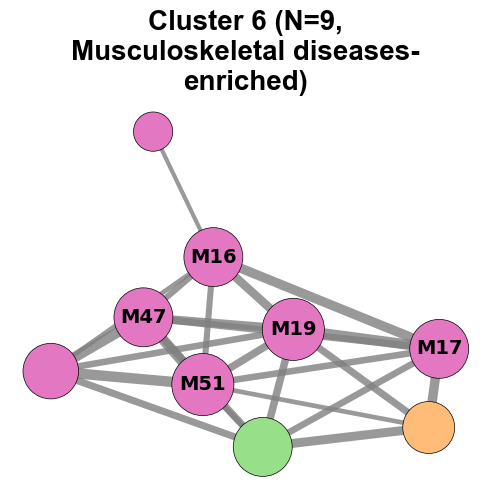

In [229]:
G = plot_one_cluster_network(
    cohort="aou",
    cluster_id=6,
    min_edge_weight=0,
    label_top_n=5,
    figsize=(5, 5)
)

### Fig3b. UKB spectral clustering

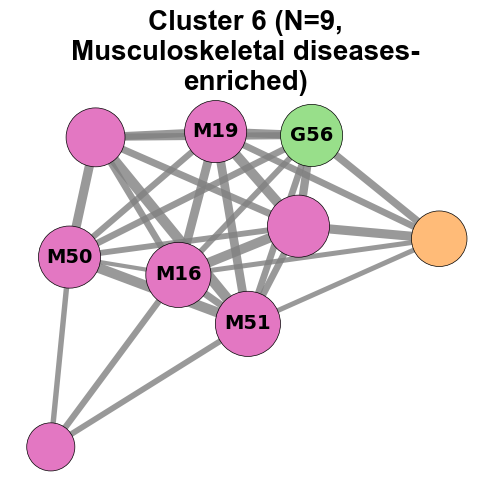

In [24]:
G = plot_one_cluster_network(
    cohort="ukb",
    cluster_id=6,
    min_edge_weight=0,
    label_top_n=5,
    figsize=(5, 5)
)